## Основной график

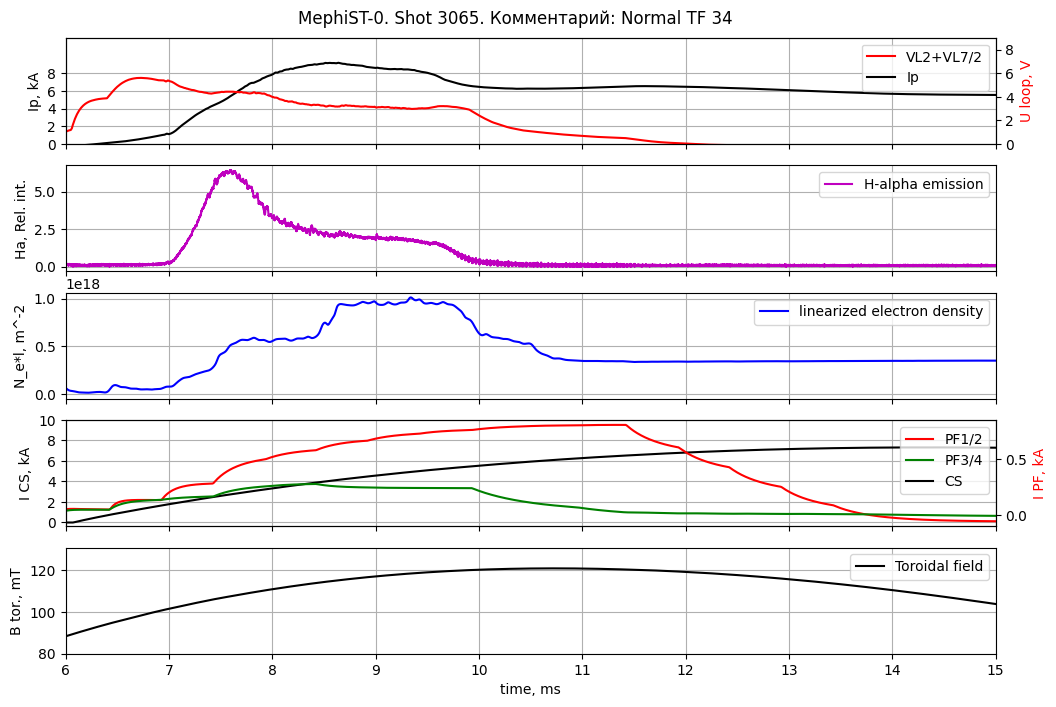

In [1]:
import mephistdatakit as mdk
import matplotlib.pyplot as plt

SHOT_NUMBER = 3065 # номер импульса, для которого будет строить график

# Создаем объект клиентского приложения с токеном, указанным в файле config.yaml
client = mdk.Client()

if not SHOT_NUMBER in client.get_shots_list():
    print("Данный номер импульса отсутствует в базе данных!")

shot = mdk.Shot(client.get_shot(SHOT_NUMBER))

time_Ip, current_Ip = shot.get_plasma_current()
time_VL2, VL2 = shot.get_voltage_loop(2)
time_VL7, VL7 = shot.get_voltage_loop(7)
time_Photodiode, inten_Photodiote = shot.get_emission()
time_density, density = shot.get_plasma_density()
time_int, inductor_current = shot.get_inductor_current()
time_pol1, I_PF1 = shot.get_pol_coils_current(1)
time_pol3, I_PF3 = shot.get_pol_coils_current(3)
time_B_phi, B_phi = shot.get_torfield()

# Make basic plots 
fig, ax = plt.subplots(5, 1,figsize=(12,8))
# set time range
tmin = 6
tmax = 15

# plot with plasma current and loop voltages
ax[0].plot(time_Ip, current_Ip,'k',label='Ip')
ax[0].set_ylabel('Ip, kA')
ax[0].set_ylim([0,12])
ax[0].set_yticks(range(0, 10, 2))
ax[0].xaxis.set_ticklabels([])
ax[0].grid()
ax[0].set_xlim([tmin,tmax])
ax[0].xaxis.set_ticklabels([])
ax2 = ax[0].twinx()
ax2.set_xlim([tmin,tmax])
ax2.plot(time_VL2, (VL2+VL7)/2,'r',label='VL2+VL7/2')
ax2.plot([], [], 'k', label = 'Ip')
ax2.legend()
ax2.set_ylim([0,9])
ax2.set_ylabel('U loop, V',color='r')
ax2.set_yticks(range(0,9,2))

# plot with H-alpha emission
ax[1].plot(time_Photodiode, abs(inten_Photodiote),'m', label ="H-alpha emission")
ax[1].set_xlim([tmin,tmax])
ax[1].grid()
ax[1].legend()
ax[1].set_ylabel('Ha, Rel. int.')
ax[1].xaxis.set_ticklabels([])

# plot with electron density
ax[2].plot(time_density, density,'b', label ="linearized electron density")
ax[2].set_xlim([tmin,tmax])
ax[2].xaxis.set_ticklabels([])
ax[2].grid()
ax[2].legend()
ax[2].set_ylabel('N_e*l, m^-2')

# plot with currents in central solenoid and some poloidal field coils
ax[3].plot(time_int, inductor_current,'k',  label='CS')
ax[3].set_ylabel('I CS, kA',color='k')
ax[3].xaxis.set_ticklabels([])
ax[3].set_yticks(range(0,12,2))
ax[3].grid()
ax1 = ax[3].twinx()
ax1.set_xlim([tmin,tmax])
ax1.set_ylabel('I PF, kA',color='r')
ax1.plot(time_pol1, I_PF1,'r',label='PF1/2')
ax1.plot(time_pol3, I_PF3,'g',label='PF3/4')
ax1.plot([], [], 'k', label = 'CS')
ax1.legend()

# plot with toroidal field
ax[4].plot(time_B_phi, B_phi,'k', label="Toroidal field")
ax[4].set_ylim([80, max(B_phi)+10])
#ax[4].set_yticks(range(70,150,25))
ax[4].grid()
ax[4].set_ylabel('B tor., mT')
ax[4].set_xlabel('time, ms')
ax[4].legend()
#ax[4].xaxis.set_ticklabels([])
ax[4].set_xlim([tmin,tmax])

fig.suptitle(f'MephiST-0. Shot {SHOT_NUMBER}. Комментарий: {shot.get_comment().replace('\n', " ")}', y = 0.915)
plt.show()

## Обзорный оптический спектр

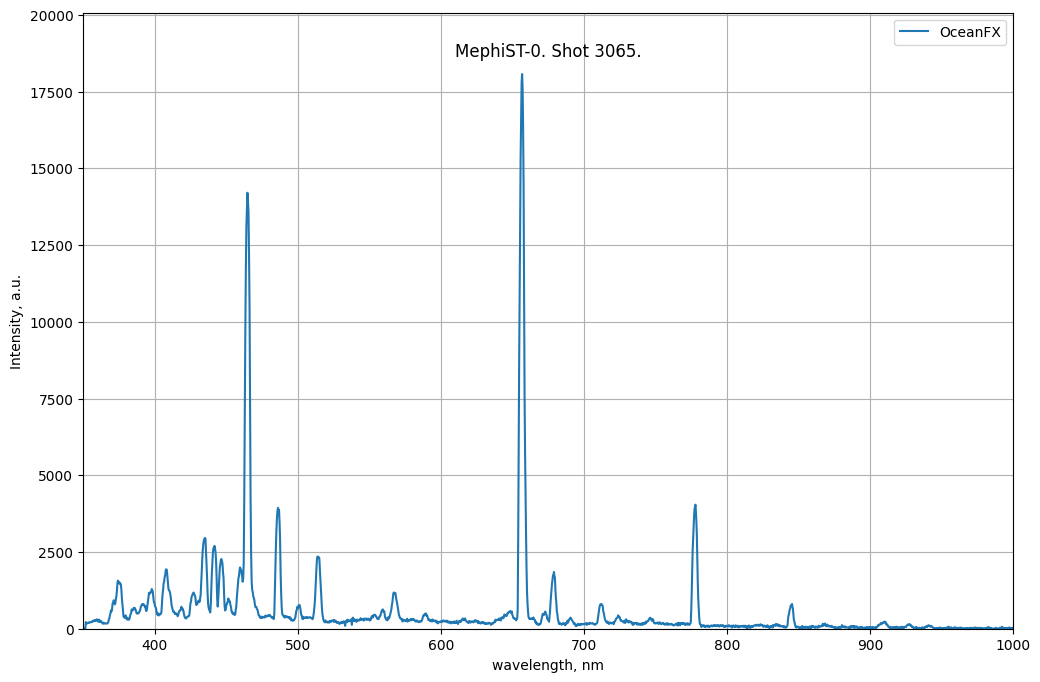

In [4]:
wavelengths_OceanFX, intensities_OceanFX = shot.get_emission_spectrum()

fig, ax = plt.subplots(figsize = (12,8))
ax.plot(wavelengths_OceanFX,intensities_OceanFX, label='OceanFX')
ax.set_xlim([350,1000])
ax.set_ylim([0,max(intensities_OceanFX)+2000])
ax.set_xlabel('wavelength, nm')
ax.legend()
ax.set_ylabel('Intensity, a.u.')
ax.grid()
ax.set_title(f'MephiST-0. Shot {SHOT_NUMBER}.', y = 0.915)
plt.show()

## Альтернативный общий график

Выстрел 3065: давление = 1.6009e-04 мБар, Ip_max_by_abs = 9.17 кА, газ = H2
Выстрел 3065: давление = 1.6009e-04 мБар, Ip_max_by_abs = 9.17 кА, газ = H2


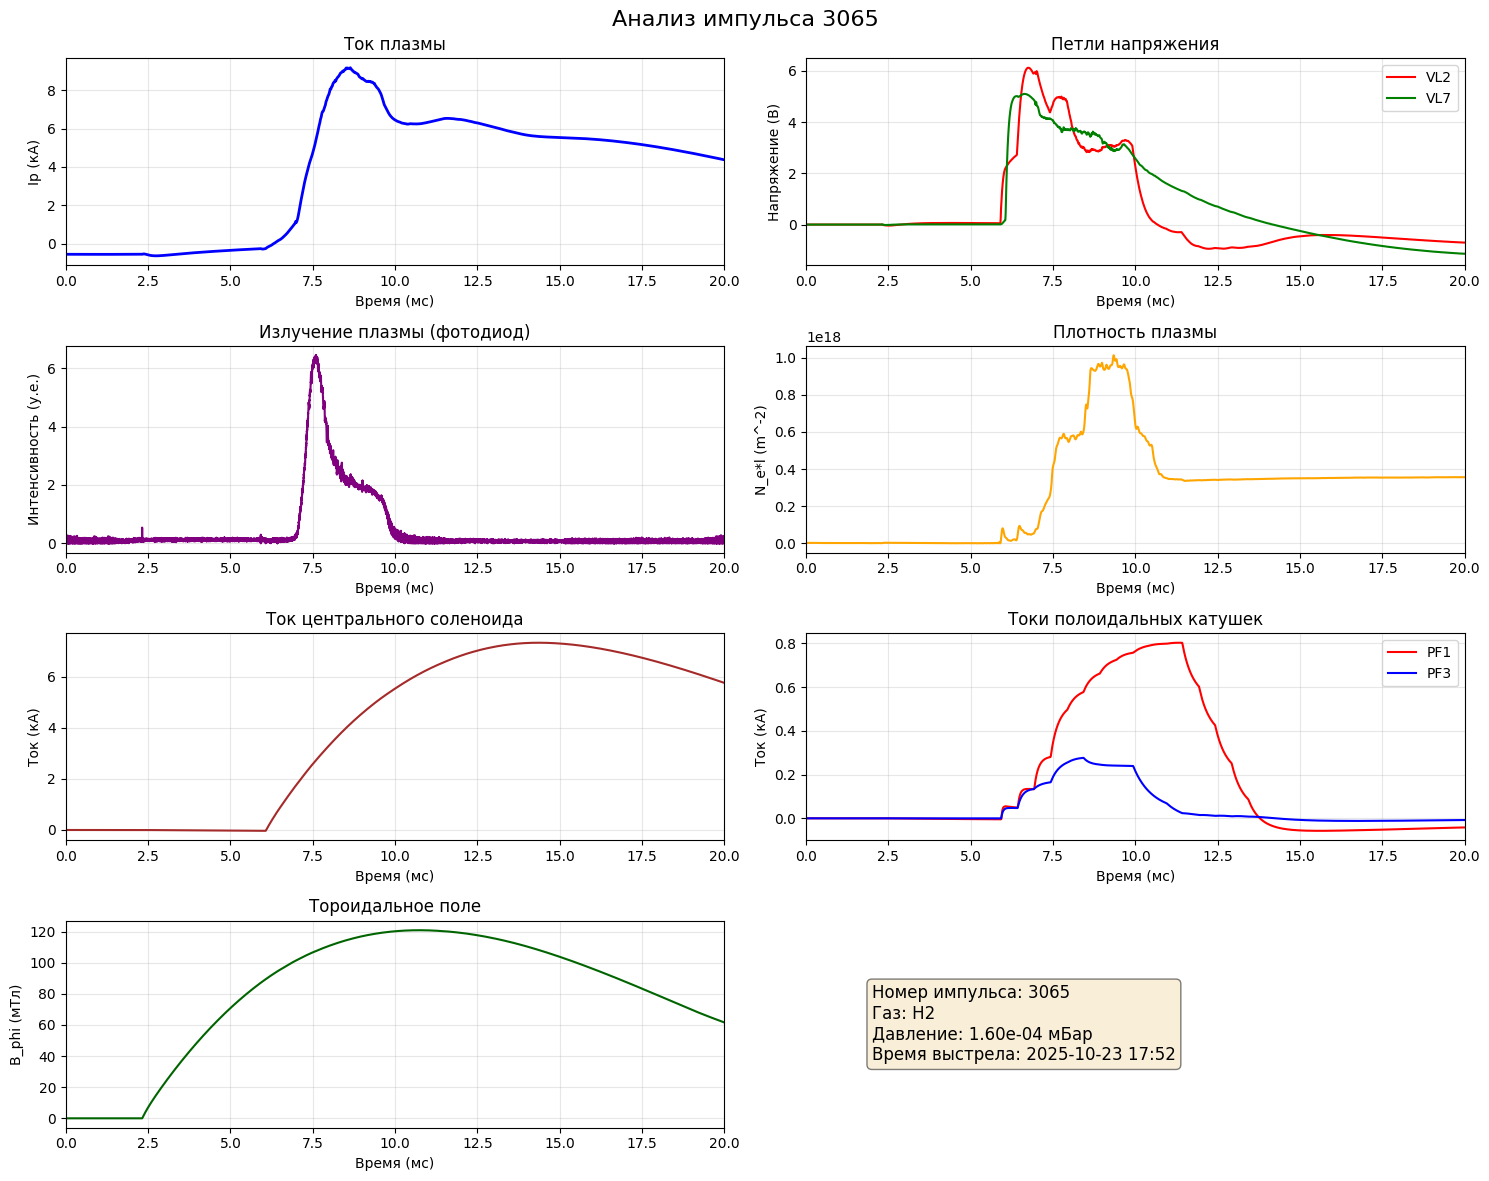

Выстрел 3065: давление = 1.6009e-04 мБар, Ip_max_by_abs = 9.17 кА, газ = H2
Выстрел 3066: давление = 1.8472e-04 мБар, Ip_max_by_abs = 8.98 кА, газ = H2
Выстрел 3067: давление = 1.8472e-04 мБар, Ip_max_by_abs = 9.38 кА, газ = H2
Импульс 3065: Ip_max = 9.17 кА, газ = H2
Импульс 3066: Ip_max = 8.98 кА, газ = H2
Импульс 3067: Ip_max = 9.38 кА, газ = H2


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

def process_shot(shot, return_full_signal: bool = False):
    """
    Обрабатывает выстрел с использованием методов класса Shot.
    
    Args:
        shot: Объект класса Shot из mephistdatakit
        return_full_signal: Если True, возвращает полный сигнал тока плазмы
        
    Returns:
        Если return_full_signal=True: (shot_id, pressure, Ip_max_by_abs, gas_type, time_Ip, Ip_ka)
        Иначе: (shot_id, pressure, Ip_max_by_abs, gas_type)
    """
    try:
        # Получаем основные параметры выстрела
        shot_id = shot.get_shot_id()
        gas_type = shot.get_gas()
        pressure = shot.get_pressure()
        
        if shot_id is None:
            print(f"Не удалось получить номер импульса")
            return _return_none(return_full_signal)
        
        # Получаем ток плазмы
        time_Ip, Ip = shot.get_plasma_current()
        
        if len(time_Ip) == 0 or len(Ip) == 0:
            print(f"Выстрел {shot_id}: не удалось получить ток плазмы")
            return _return_none(return_full_signal)
        
        # Находим максимальный ток плазмы
        # time_Ip в мс, как указано в методе get_plasma_current
        time_ms = time_Ip if time_Ip[-1] > 1 else time_Ip * 1000  # Проверяем единицы измерения
        
        t_mask = (time_ms >= 0) & (time_ms <= 200)
        
        if np.any(t_mask):
            Ip_interval = Ip[t_mask]
            if len(Ip_interval) > 0:
                max_abs_idx = np.argmax(np.abs(Ip_interval))
                Ip_max_by_abs = np.abs(Ip_interval[max_abs_idx])  # В кА
            else:
                max_abs_idx = np.argmax(np.abs(Ip))
                Ip_max_by_abs = np.abs(Ip[max_abs_idx])  # В кА
        else:
            max_abs_idx = np.argmax(np.abs(Ip))
            Ip_max_by_abs = np.abs(Ip[max_abs_idx])  # В кА
        
        print(f"Выстрел {shot_id}: давление = {pressure:.4e} мБар, "
              f"Ip_max_by_abs = {Ip_max_by_abs:.2f} кА, газ = {gas_type}")
        
        if return_full_signal:
            # Ip уже в А из get_plasma_current(), конвертируем в кА
            return shot_id, pressure, Ip_max_by_abs, gas_type, time_ms, Ip/1000
        else:
            return shot_id, pressure, Ip_max_by_abs, gas_type
        
    except Exception as e:
        print(f"Ошибка при обработке выстрела: {str(e)[:100]}")
        return _return_none(return_full_signal)

def _return_none(return_full_signal: bool):
    """Вспомогательная функция для возврата None значений."""
    if return_full_signal:
        return None, None, None, None, None, None
    return None, None, None, None

# Пример использования с вашей библиотекой
def process_multiple_shots(client, shot_numbers: list, return_full_signal: bool = False):
    """
    Обрабатывает несколько выстрелов.
    
    Args:
        client: Клиент mephistdatakit
        shot_numbers: Список номеров импульсов
        return_full_signal: Если True, возвращает полные сигналы
        
    Returns:
        Список результатов для каждого выстрела
    """
    results = []
    
    available_shots = client.get_shots_list()
    
    for shot_number in shot_numbers:
        if shot_number not in available_shots:
            print(f"Импульс {shot_number} отсутствует в базе данных!")
            continue
            
        shot = mdk.Shot(client.get_shot(shot_number))
        result = process_shot(shot, return_full_signal)
        
        if result[0] is not None:  # Проверяем, что shot_id не None
            results.append(result)
    
    return results

# Пример визуализации с использованием вашей библиотеки
def plot_shot_analysis(shot, shot_number: Optional[int] = None):
    """
    Строит комплексный анализ выстрела.
    
    Args:
        shot: Объект класса Shot
        shot_number: Номер импульса (если не указан, берется из shot)
    """
    if shot_number is None:
        shot_number = shot.get_shot_id()
    
    # Получаем все данные
    time_Ip, Ip = shot.get_plasma_current()
    time_VL2, VL2 = shot.get_voltage_loop(2)
    time_VL7, VL7 = shot.get_voltage_loop(7)
    time_Photodiode, inten_Photodiote = shot.get_emission()
    time_density, density = shot.get_plasma_density()
    time_int, inductor_current = shot.get_inductor_current()
    time_pol1, I_PF1 = shot.get_pol_coils_current(1)
    time_pol3, I_PF3 = shot.get_pol_coils_current(3)
    time_B_phi, B_phi = shot.get_torfield()
    
    # Создаем график
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    fig.suptitle(f'Анализ импульса {shot_number}', fontsize=16)
    
    # 1. Ток плазмы
    if len(time_Ip) > 0 and len(Ip) > 0:
        axes[0, 0].plot(time_Ip, Ip, 'b-', linewidth=2)
        axes[0, 0].set_xlabel('Время (мс)')
        axes[0, 0].set_ylabel('Ip (кА)')
        axes[0,0].set_xlim(0,20)
        axes[0, 0].set_title('Ток плазмы')
        axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Петли напряжения
    if len(time_VL2) > 0 and len(VL2) > 0:
        axes[0, 1].plot(time_VL2, VL2, 'r-', label='VL2')
    if len(time_VL7) > 0 and len(VL7) > 0:
        axes[0, 1].plot(time_VL7, VL7, 'g-', label='VL7')
    axes[0, 1].set_xlabel('Время (мс)')
    axes[0, 1].set_ylabel('Напряжение (В)')
    axes[0, 1].set_xlim(0,20)
    axes[0, 1].set_title('Петли напряжения')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Излучение плазмы
    if len(time_Photodiode) > 0 and len(inten_Photodiote) > 0:
        axes[1, 0].plot(time_Photodiode, inten_Photodiote, 'purple')
        axes[1, 0].set_xlabel('Время (мс)')
        axes[1, 0].set_xlim(0,20)
        axes[1, 0].set_ylabel('Интенсивность (у.е.)')
        axes[1, 0].set_title('Излучение плазмы (фотодиод)')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Плотность плазмы
    if len(time_density) > 0 and len(density) > 0:
        axes[1, 1].plot(time_density, density, 'orange')
        axes[1, 1].set_xlabel('Время (мс)')
        axes[1, 1].set_ylabel('N_e*l (m^-2)')
        axes[1, 1].set_xlim(0,20)
        axes[1, 1].set_title('Плотность плазмы')
        axes[1, 1].grid(True, alpha=0.3)
    
    # 5. Ток индуктора
    if len(time_int) > 0 and len(inductor_current) > 0:
        axes[2, 0].plot(time_int, inductor_current, 'brown')
        axes[2, 0].set_xlabel('Время (мс)')
        axes[2, 0].set_ylabel('Ток (кА)')
        axes[2, 0].set_xlim(0,20)
        axes[2, 0].set_title('Ток центрального соленоида')
        axes[2, 0].grid(True, alpha=0.3)
    
    # 6. Токи полоидальных катушек
    if len(time_pol1) > 0 and len(I_PF1) > 0:
        axes[2, 1].plot(time_pol1, I_PF1, 'red', label='PF1')
    if len(time_pol3) > 0 and len(I_PF3) > 0:
        axes[2, 1].plot(time_pol3, I_PF3, 'blue', label='PF3')
    axes[2, 1].set_xlabel('Время (мс)')
    axes[2, 1].set_ylabel('Ток (кА)')
    axes[2, 1].set_xlim(0,20)
    axes[2, 1].set_title('Токи полоидальных катушек')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    # 7. Тороидальное поле
    if len(time_B_phi) > 0 and len(B_phi) > 0:
        axes[3, 0].plot(time_B_phi, B_phi, 'darkgreen')
        axes[3, 0].set_xlabel('Время (мс)')
        axes[3, 0].set_ylabel('B_phi (мТл)')
        axes[3, 0].set_xlim(0,20)
        axes[3, 0].set_title('Тороидальное поле')
        axes[3, 0].grid(True, alpha=0.3)
    
    # 8. Информация о выстреле
    axes[3, 1].axis('off')
    info_text = f"Номер импульса: {shot_number}\n"
    info_text += f"Газ: {shot.get_gas()}\n"
    info_text += f"Давление: {shot.get_pressure():.2e} мБар\n"
    info_text += f"Время выстрела: {shot.get_shot_time()}"
    
    axes[3, 1].text(0.1, 0.5, info_text, fontsize=12,
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

# Пример использования
if __name__ == "__main__":
    import mephistdatakit as mdk
    
    # Создаем клиент
    client = mdk.Client()
    
    # Пример обработки одного выстрела
    SHOT_NUMBER = 3065
    
    if SHOT_NUMBER in client.get_shots_list():
        shot = mdk.Shot(client.get_shot(SHOT_NUMBER))
        
        # Обработка с возвратом только основных параметров
        shot_id, pressure, Ip_max, gas_type = process_shot(shot)
        
        # Обработка с возвратом полного сигнала
        shot_id, pressure, Ip_max, gas_type, time_full, Ip_full = process_shot(shot, return_full_signal=True)
        
        # Построение комплексного анализа
        fig = plot_shot_analysis(shot, SHOT_NUMBER)
        plt.show()
        
        # Обработка нескольких выстрелов
        shot_numbers = [3065, 3066, 3067]
        results = process_multiple_shots(client, shot_numbers)
        
        # Анализ результатов
        for shot_id, pressure, Ip_max, gas_type in results:
            print(f"Импульс {shot_id}: Ip_max = {Ip_max:.2f} кА, газ = {gas_type}")
    else:
        print(f"Импульс {SHOT_NUMBER} отсутствует в базе данных!")